# Multi-City Shelter Analysis

Standardizes and merges intake/outcome data from Austin (TX), Sonoma County (CA), and Norfolk (VA) into a single dataset with a common schema, so trends can be compared across cities and filtered by city in Tableau.

Target schema: `city`, `animal_id`, `animal_type`, `intake_type`, `sterilized`, `outcome_category`, `intake_year`, `intake_month`, `length_of_stay`

In [1]:
import pandas as pd
import numpy as np
import os

DATA_DIR = '/Users/victorialarrazolo/Documents/animal_shelter_project/data'
TABLEAU_DIR = '/Users/victorialarrazolo/Documents/animal_shelter_project/tableau'

austin_intakes_raw = pd.read_csv(os.path.join(DATA_DIR, 'Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260811.csv'))
austin_outcomes_raw = pd.read_csv(os.path.join(DATA_DIR, 'Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260811.csv'))
sonoma_raw = pd.read_csv(os.path.join(DATA_DIR, 'Sonoma_Animal_Shelter_Intake_and_Outcome.csv'))
norfolk_raw = pd.read_csv(os.path.join(DATA_DIR, 'Norfolk_Animal_Care_and_Adoption_Center_(NACC)_20260821.csv'))

print(f"Austin intakes:  {austin_intakes_raw.shape}")
print(f"Austin outcomes: {austin_outcomes_raw.shape}")
print(f"Sonoma:          {sonoma_raw.shape}")
print(f"Norfolk:         {norfolk_raw.shape}")

Austin intakes:  (173812, 12)
Austin outcomes: (173775, 12)
Sonoma:          (34047, 24)
Norfolk:         (59540, 16)


*Note: `data/` contains two identical copies of the Norfolk file (one with a `(1)` suffix from a duplicate download). Only one is loaded above; the duplicate can be deleted.*

## Austin

Austin's intakes and outcomes are separate event logs (not one row per shelter stay), so they need to be paired up first. Animal IDs repeat for animals with multiple shelter visits (~17.5K repeat rows on each side), so a plain merge on `Animal ID` would cross-join those animals and produce wrong `length_of_stay` values. Instead, each intake is matched to the nearest outcome for the same animal that happened on or after it, using `merge_asof`.

In [2]:
austin_intakes = austin_intakes_raw.copy()
austin_outcomes = austin_outcomes_raw.copy()

austin_intakes['intake_datetime'] = pd.to_datetime(austin_intakes['DateTime'], utc=True)
austin_outcomes['outcome_datetime'] = pd.to_datetime(austin_outcomes['DateTime'], format='mixed', utc=True)

austin_intakes = austin_intakes[austin_intakes['Animal Type'].isin(['Dog', 'Cat'])].copy()
austin_outcomes = austin_outcomes[austin_outcomes['Animal Type'].isin(['Dog', 'Cat'])].copy()

austin_intakes = austin_intakes.sort_values('intake_datetime')
austin_outcomes = austin_outcomes.sort_values('outcome_datetime')

austin_merged = pd.merge_asof(
    austin_intakes,
    austin_outcomes[['Animal ID', 'outcome_datetime', 'Outcome Type']],
    left_on='intake_datetime',
    right_on='outcome_datetime',
    by='Animal ID',
    direction='forward'
)

AUSTIN_INTAKE_TYPE_MAP = {
    'Stray': 'Stray',
    'Owner Surrender': 'Owner Surrender',
    'Public Assist': 'Public Assist',
}

def austin_sterilization(sex):
    if pd.isna(sex):
        return 'Unknown'
    sex = sex.strip()
    if sex in ('Spayed Female', 'Neutered Male'):
        return 'Sterilized'
    if sex in ('Intact Female', 'Intact Male'):
        return 'Intact'
    return 'Unknown'

AUSTIN_OUTCOME_MAP = {
    'Adoption': 'Adopted',
    'Rto-Adopt': 'Adopted',
    'Return to Owner': 'Returned to Owner',
    'Transfer': 'Transferred',
    'Euthanasia': 'Euthanized',
}

austin_std = pd.DataFrame({
    'city': 'Austin',
    'animal_id': austin_merged['Animal ID'],
    'animal_type': austin_merged['Animal Type'],
    'intake_type': austin_merged['Intake Type'].map(AUSTIN_INTAKE_TYPE_MAP).fillna('Other'),
    'sterilized': austin_merged['Sex upon Intake'].apply(austin_sterilization),
    'outcome_category': austin_merged['Outcome Type'].map(AUSTIN_OUTCOME_MAP).fillna('Other'),
    'intake_year': austin_merged['intake_datetime'].dt.year,
    'intake_month': austin_merged['intake_datetime'].dt.strftime('%B'),
    'length_of_stay': (austin_merged['outcome_datetime'] - austin_merged['intake_datetime']).dt.days,
})

print(f"Austin standardized: {austin_std.shape}")
austin_std.head()

Austin standardized: (163932, 9)


,city,animal_id,animal_type,intake_type,sterilized,outcome_category,intake_year,intake_month,length_of_stay
0,Austin,A521520,Dog,Stray,Sterilized,Returned to Owner,2013,October,0.0
1,Austin,A664235,Cat,Stray,Unknown,Transferred,2013,October,0.0
2,Austin,A664236,Cat,Stray,Unknown,Transferred,2013,October,0.0
3,Austin,A664237,Cat,Stray,Unknown,Transferred,2013,October,0.0
4,Austin,A664233,Dog,Stray,Intact,Euthanized,2013,October,0.0


## Sonoma County

Sonoma's file is already one row per shelter stay, with intake and outcome columns and a `Days in Shelter` field already computed — no matching needed.

In [3]:
sonoma = sonoma_raw.copy()
sonoma = sonoma[sonoma['Type'].isin(['DOG', 'CAT'])].copy()
sonoma['Intake Date'] = pd.to_datetime(sonoma['Intake Date'], format='%m/%d/%Y')

SONOMA_INTAKE_TYPE_MAP = {
    'STRAY': 'Stray',
    'OWNER SURRENDER': 'Owner Surrender',
}

def sonoma_sterilization(sex):
    if pd.isna(sex):
        return 'Unknown'
    sex = sex.strip()
    if sex in ('Neutered', 'Spayed'):
        return 'Sterilized'
    if sex in ('Male', 'Female'):
        return 'Intact'
    return 'Unknown'

SONOMA_OUTCOME_MAP = {
    'ADOPTION': 'Adopted',
    'RETURN TO OWNER': 'Returned to Owner',
    'TRANSFER': 'Transferred',
    'EUTHANIZE': 'Euthanized',
}

sonoma_std = pd.DataFrame({
    'city': 'Sonoma County',
    'animal_id': sonoma['Animal ID'],
    'animal_type': sonoma['Type'].str.title(),
    'intake_type': sonoma['Intake Type'].map(SONOMA_INTAKE_TYPE_MAP).fillna('Other'),
    'sterilized': sonoma['Sex'].apply(sonoma_sterilization),
    'outcome_category': sonoma['Outcome Type'].map(SONOMA_OUTCOME_MAP).fillna('Other'),
    'intake_year': sonoma['Intake Date'].dt.year,
    'intake_month': sonoma['Intake Date'].dt.strftime('%B'),
    'length_of_stay': sonoma['Days in Shelter'],
})

print(f"Sonoma standardized: {sonoma_std.shape}")
sonoma_std.head()

Sonoma standardized: (31131, 9)


,city,animal_id,animal_type,intake_type,sterilized,outcome_category,intake_year,intake_month,length_of_stay
0,Sonoma County,A422697,Dog,Stray,Intact,Euthanized,2023,December,35
1,Sonoma County,A422443,Dog,Stray,Intact,Euthanized,2023,November,41
2,Sonoma County,A422038,Dog,Stray,Intact,Euthanized,2023,November,58
3,Sonoma County,A423685,Dog,Stray,Sterilized,Returned to Owner,2024,January,3
4,Sonoma County,A425655,Dog,Stray,Intact,Returned to Owner,2024,April,1


## Norfolk

Also already one row per shelter stay, with separate intake and outcome date columns to compute `length_of_stay` from.

In [4]:
norfolk = norfolk_raw.copy()
norfolk = norfolk[norfolk['Animal Type'].isin(['Dog', 'Cat'])].copy()
norfolk['Intake Date'] = pd.to_datetime(norfolk['Intake Date'], format='%m/%d/%Y')
norfolk['Outcome Date'] = pd.to_datetime(norfolk['Outcome Date'], format='%m/%d/%Y')

NORFOLK_INTAKE_TYPE_MAP = {
    'Stray': 'Stray',
    'Owner Surrendered': 'Owner Surrender',
    'Owner/Guardian Surrender': 'Owner Surrender',
}

def norfolk_sterilization(sex):
    if pd.isna(sex):
        return 'Unknown'
    sex = sex.strip()
    if sex in ('Spayed Female', 'Neutered Male'):
        return 'Sterilized'
    if sex in ('Male', 'Female'):
        return 'Intact'
    return 'Unknown'

NORFOLK_OUTCOME_MAP = {
    'Adoption': 'Adopted',
    'Return to Owner': 'Returned to Owner',
    'Return to Owner/Guardian': 'Returned to Owner',
    'Transfer': 'Transferred',
    'Transfer Out': 'Transferred',
    'Euthanized': 'Euthanized',
    'Euthanasia': 'Euthanized',
}

norfolk_std = pd.DataFrame({
    'city': 'Norfolk',
    'animal_id': norfolk['Animal ID'],
    'animal_type': norfolk['Animal Type'],
    'intake_type': norfolk['Intake Type'].map(NORFOLK_INTAKE_TYPE_MAP).fillna('Other'),
    'sterilized': norfolk['Sex'].apply(norfolk_sterilization),
    'outcome_category': norfolk['Outcome Type'].map(NORFOLK_OUTCOME_MAP).fillna('Other'),
    'intake_year': norfolk['Intake Date'].dt.year,
    'intake_month': norfolk['Intake Date'].dt.strftime('%B'),
    'length_of_stay': (norfolk['Outcome Date'] - norfolk['Intake Date']).dt.days,
})

print(f"Norfolk standardized: {norfolk_std.shape}")
norfolk_std.head()

Norfolk standardized: (53569, 9)


,city,animal_id,animal_type,intake_type,sterilized,outcome_category,intake_year,intake_month,length_of_stay
0,Norfolk,A0060747083,Dog,Stray,Intact,Returned to Owner,2026,April,0
1,Norfolk,A0060747314,Dog,Other,Intact,Euthanized,2026,April,0
2,Norfolk,A0060746821,Dog,Other,Intact,Returned to Owner,2026,April,0
4,Norfolk,A0055675678,Dog,Stray,Sterilized,Returned to Owner,2026,April,0
6,Norfolk,A0060727683,Cat,Other,Sterilized,Euthanized,2026,April,0


## Combine and validate

In [5]:
combined = pd.concat([austin_std, sonoma_std, norfolk_std], ignore_index=True)

print(f"Combined shape: {combined.shape}")
print()
print("Rows by city:")
print(combined['city'].value_counts())
print()
print("animal_type values:", combined['animal_type'].unique())
print("intake_type values:", combined['intake_type'].unique())
print("sterilized values:", combined['sterilized'].unique())
print("outcome_category values:", combined['outcome_category'].unique())
print()
print("Null counts:")
print(combined.isnull().sum())
print()
print("length_of_stay describe (all cities):")
print(combined.groupby('city')['length_of_stay'].describe())

Combined shape: (248632, 9)

Rows by city:
city
Austin           163932
Norfolk           53569
Sonoma County     31131
Name: count, dtype: int64

animal_type values: ['Dog' 'Cat']
intake_type values: ['Stray' 'Owner Surrender' 'Public Assist' 'Other']
sterilized values: ['Sterilized' 'Unknown' 'Intact']
outcome_category values: ['Returned to Owner' 'Transferred' 'Euthanized' 'Adopted' 'Other']

Null counts:


city                   0
animal_id              0
animal_type            0
intake_type            0
sterilized             0
outcome_category       0
intake_year            0
intake_month           0
length_of_stay      1490
dtype: int64

length_of_stay describe (all cities):
                  count       mean        std  min  25%  50%   75%     max
city                                                                      
Austin         162442.0  21.612169  49.421743  0.0  2.0  6.0  21.0  1912.0
Norfolk         53569.0  13.155743  30.712931  0.0  1.0  4.0  12.0   856.0
Sonoma County   31131.0  20.199351  43.748974  0.0  1.0  9.0  25.0  3704.0


## Export for Tableau

`city` is included as a plain column so it can be used as a filter/dimension in Tableau.

In [6]:
output_path = os.path.join(TABLEAU_DIR, 'multi_city_combined.csv')
combined.to_csv(output_path, index=False)
print(f"Saved {len(combined):,} rows to {output_path}")

Saved 248,632 rows to /Users/victorialarrazolo/Documents/animal_shelter_project/tableau/multi_city_combined.csv


## Predictive analysis: what drives euthanasia risk at intake?

Rather than just describing outcome rates, this section fits a model to predict whether an animal will be **euthanized vs. live-released** (adopted, returned to owner, or transferred), using only information known **at intake time**: `city`, `animal_type`, `intake_type`, `sterilized`, and `intake_month`.

A few modeling choices worth calling out:
- **`length_of_stay` is excluded.** It's only known once the animal has already left the shelter, so using it to predict the outcome would be data leakage (the outcome determines the length of stay, not the other way around).
- **`outcome_category == 'Other'` rows are dropped** for this analysis (died, disposal, missing, stolen, relocated). That bucket mixes several different situations that aren't really "euthanasia decisions," so including them would muddy the target.
- **Euthanasia is a minority class (~8% of rows)**, so `class_weight='balanced'` is used and the model is judged on precision/recall/ROC AUC rather than raw accuracy, which would be misleading on imbalanced data.

Two models are fit: a **logistic regression** (coefficients are directly interpretable as which factors raise or lower euthanasia odds) and a shallow **decision tree** (visualizes the decision splits directly).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

FEATURES = ['city', 'animal_type', 'intake_type', 'sterilized', 'intake_month']

model_df = combined[combined['outcome_category'] != 'Other'].copy()
model_df['is_euthanized'] = (model_df['outcome_category'] == 'Euthanized').astype(int)

X = model_df[FEATURES]
y = model_df['is_euthanized']

print(f"Modeling rows: {len(model_df):,}")
print(f"Euthanized rate: {y.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), FEATURES)
])

Modeling rows: 234,456
Euthanized rate: 8.0%


### Logistic regression

Fit on the one-hot encoded intake features. `class_weight='balanced'` reweights the loss so the minority (euthanized) class isn't ignored in favor of always predicting "live release."

In [8]:
logreg = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Live Release', 'Euthanized']))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

Live Release       0.97      0.77      0.86     43125
  Euthanized       0.22      0.73      0.33      3767

    accuracy                           0.77     46892
   macro avg       0.59      0.75      0.60     46892
weighted avg       0.91      0.77      0.82     46892

ROC AUC: 0.808


**Coefficient interpretation.** Each coefficient is a log-odds effect relative to the dropped baseline category for that feature (e.g. for `intake_type`, the baseline is whichever category `OneHotEncoder(drop='first')` dropped). `odds_ratio = exp(coefficient)`: a value above 1 means that feature raises euthanasia odds relative to baseline, below 1 means it lowers them.

In [9]:
feature_names = logreg.named_steps['prep'].get_feature_names_out()
coefs = logreg.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs)
}).sort_values('coefficient', ascending=False)

print("Features associated with HIGHER euthanasia odds:")
print(coef_df.head(8).to_string(index=False))
print()
print("Features associated with LOWER euthanasia odds:")
print(coef_df.tail(8).to_string(index=False))

Features associated with HIGHER euthanasia odds:
                         feature  coefficient  odds_ratio
               cat__city_Norfolk     2.637931   13.984245
         cat__city_Sonoma County     2.115057    8.290057
  cat__intake_type_Public Assist     0.958857    2.608714
         cat__sterilized_Unknown     0.857604    2.357506
cat__intake_type_Owner Surrender     0.775490    2.171657
          cat__intake_type_Stray     0.270922    1.311173
      cat__intake_month_February    -0.000445    0.999555
          cat__intake_month_June    -0.023754    0.976526

Features associated with LOWER euthanasia odds:
                    feature  coefficient  odds_ratio
  cat__intake_month_January    -0.063140    0.938812
      cat__intake_month_May    -0.094628    0.909712
     cat__intake_month_July    -0.098445    0.906245
  cat__intake_month_October    -0.111081    0.894866
   cat__intake_month_August    -0.150514    0.860266
cat__intake_month_September    -0.196267    0.821793
       ca

### Decision tree (depth-limited for readability)

A shallow tree trades some predictive power for a model you can literally read as a flowchart of the biggest euthanasia-risk splits.

              precision    recall  f1-score   support

Live Release       0.97      0.86      0.91     43125
  Euthanized       0.29      0.68      0.41      3767

    accuracy                           0.84     46892
   macro avg       0.63      0.77      0.66     46892
weighted avg       0.91      0.84      0.87     46892

ROC AUC: 0.821


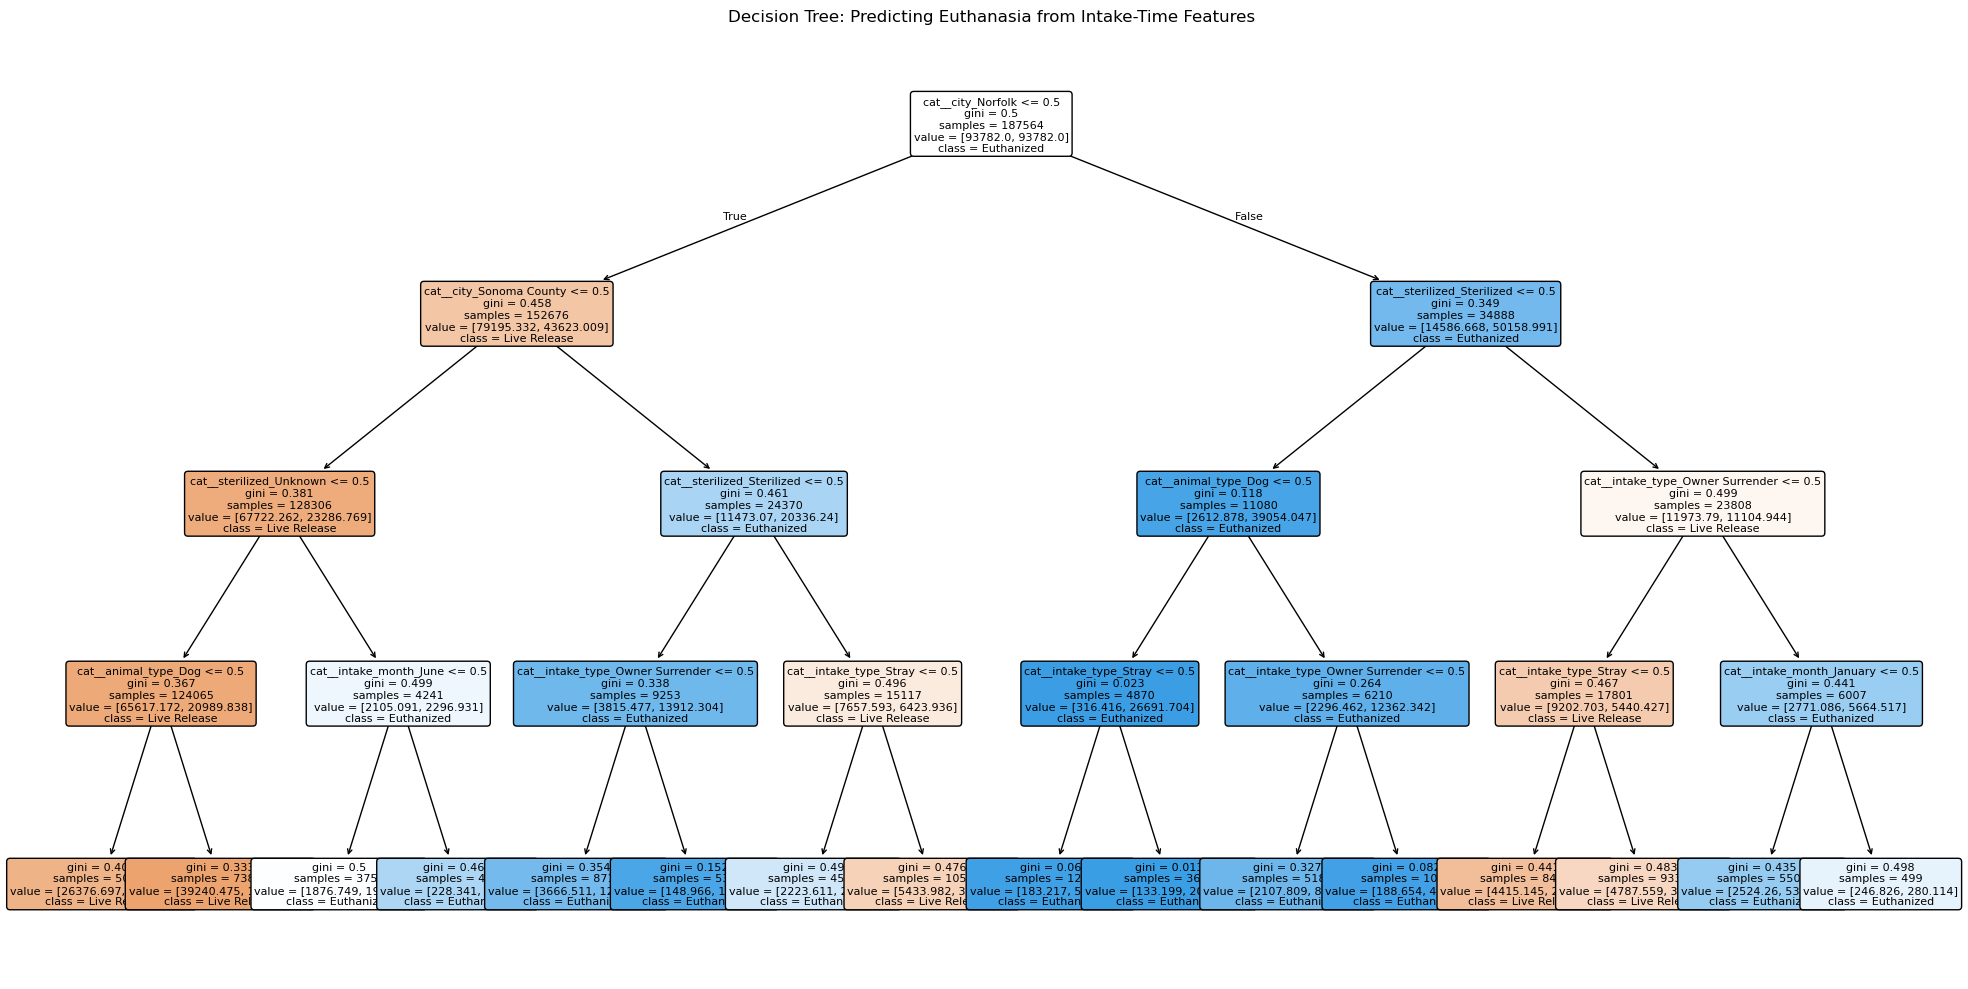

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_clf = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42))
])
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tree, target_names=['Live Release', 'Euthanized']))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_tree):.3f}")

plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf.named_steps['clf'],
    feature_names=tree_clf.named_steps['prep'].get_feature_names_out(),
    class_names=['Live Release', 'Euthanized'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Decision Tree: Predicting Euthanasia from Intake-Time Features')
plt.tight_layout()
plt.savefig(os.path.join(TABLEAU_DIR, '..', 'notebooks', 'euthanasia_prediction_tree.png'), dpi=150, bbox_inches='tight')
plt.show()